<a href="https://colab.research.google.com/github/bohanlaii/data_class/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ File loaded successfully!


/tmp/ipykernel_2498/1374791384.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2498/1374791384.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


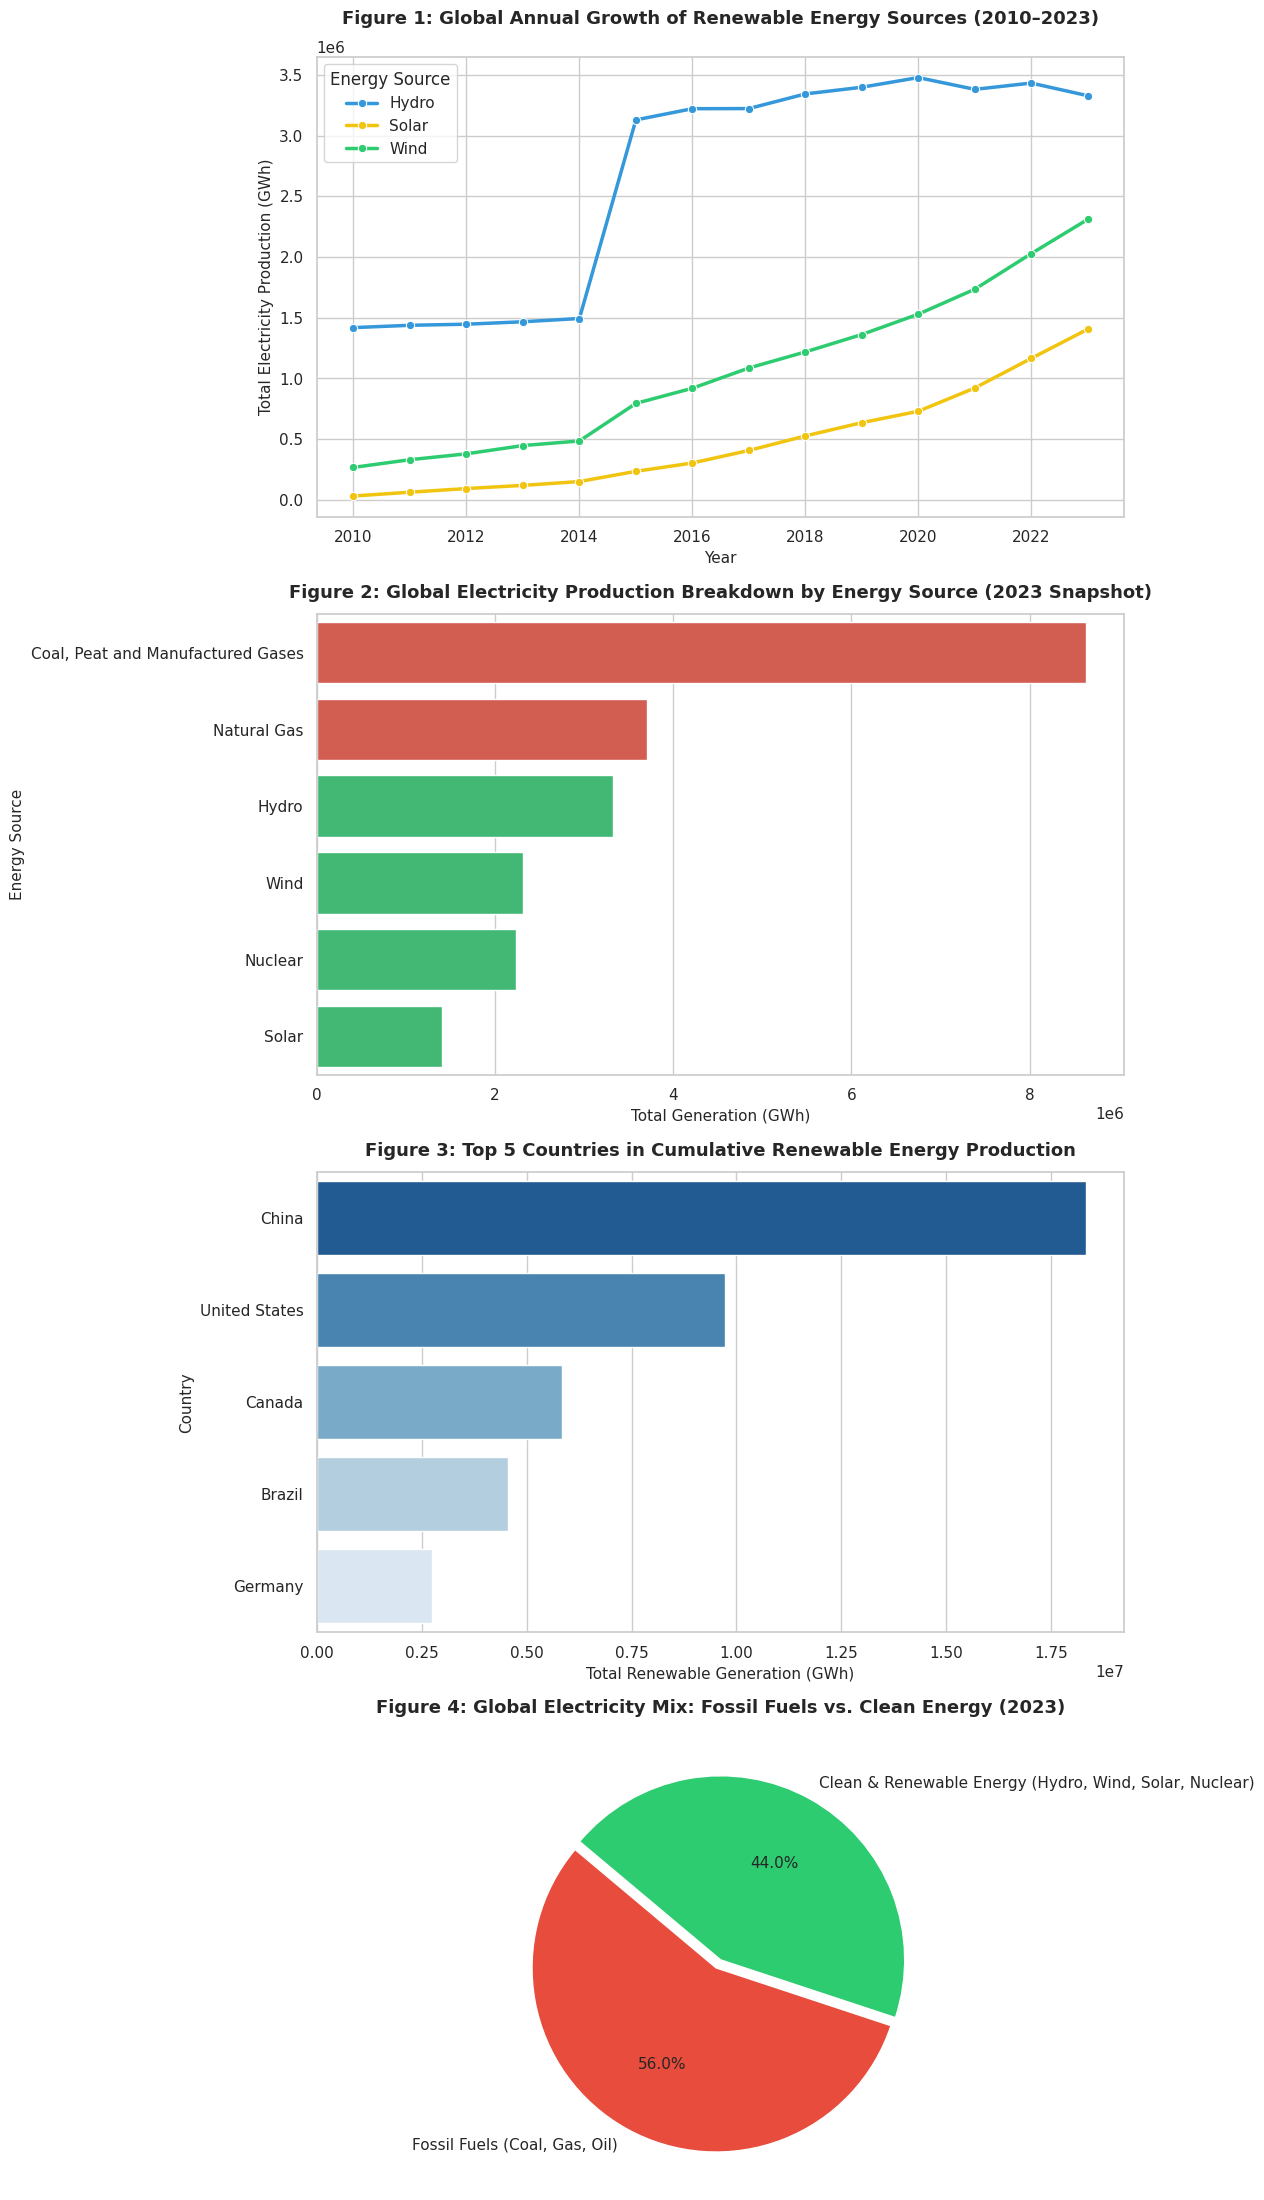

✅ All 4 high-quality EDA figures generated successfully!


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 讀取數據檔
file_name = 'global_electricity_production_data.csv'

try:
    df = pd.read_csv(file_name)
    print("✅ File loaded successfully!")
except FileNotFoundError:
    print(f"❌ Error: Could not find '{file_name}'. Please upload it to Google Colab.")

# 2. 數據預處理 (Data Cleaning)
df['date_dt'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')
net_prod = df[df['parameter'] == 'Net Electricity Production'].copy()

# 3. 建立 4 張圖表的畫布設定
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(4, 1, figsize=(12, 22))

# --- 圖一：全球再生能源歷年成長趨勢 (Line Plot) ---
renewable_techs = ['Wind', 'Solar', 'Hydro']
df_ren = net_prod[net_prod['product'].isin(renewable_techs)]
yearly_ren = df_ren.groupby([df_ren['date_dt'].dt.year, 'product'])['value'].sum().reset_index()

sns.lineplot(
    data=yearly_ren,
    x='date_dt',
    y='value',
    hue='product',
    marker='o',
    linewidth=2.5,
    ax=axes[0],
    palette=['#3498db', '#f1c40f', '#2ecc71']
)
axes[0].set_title('Figure 1: Global Annual Growth of Renewable Energy Sources (2010–2023)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Total Electricity Production (GWh)', fontsize=11)
axes[0].legend(title='Energy Source', loc='upper left')

# --- 圖二：2023 各發電來源總量對比 (Bar Plot) ---
energy_sources = ['Coal, Peat and Manufactured Gases', 'Natural Gas', 'Hydro', 'Wind', 'Nuclear', 'Solar']
df_2023 = net_prod[(net_prod['date_dt'].dt.year == 2023) & (net_prod['product'].isin(energy_sources))]
product_2023 = df_2023.groupby('product')['value'].sum().reset_index().sort_values(by='value', ascending=False)
palette_colors = ['#e74c3c' if x in ['Coal, Peat and Manufactured Gases', 'Natural Gas'] else '#2ecc71' for x in product_2023['product']]

sns.barplot(
    data=product_2023,
    x='value',
    y='product',
    palette=palette_colors,
    ax=axes[1]
)
axes[1].set_title('Figure 2: Global Electricity Production Breakdown by Energy Source (2023 Snapshot)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Total Generation (GWh)', fontsize=11)
axes[1].set_ylabel('Energy Source', fontsize=11)

# --- 圖三：前 5 大主要國家的綠能發電總量對比 (Country Comparison Bar Plot) ---
all_renewables = ['Wind', 'Solar', 'Hydro', 'Geothermal', 'Combustible Renewables', 'Other Renewables']
df_ren_countries = net_prod[net_prod['product'].isin(all_renewables)]
top_5_countries = df_ren_countries.groupby('country_name')['value'].sum().nlargest(5).reset_index()

sns.barplot(
    data=top_5_countries,
    x='value',
    y='country_name',
    palette='Blues_r',
    ax=axes[2]
)
axes[2].set_title('Figure 3: Top 5 Countries in Cumulative Renewable Energy Production', fontsize=13, fontweight='bold', pad=12)
axes[2].set_xlabel('Total Renewable Generation (GWh)', fontsize=11)
axes[2].set_ylabel('Country', fontsize=11)

# --- 圖四：全球傳統能源 vs 綠能的百分比佔比 (Pie Chart) ---
fossil_fuels = ['Coal, Peat and Manufactured Gases', 'Oil and Petroleum Products', 'Natural Gas', 'Other Combustible Non-Renewables']
clean_energy = ['Hydro', 'Wind', 'Solar', 'Geothermal', 'Nuclear', 'Combustible Renewables', 'Other Renewables']

df_2023_all = net_prod[net_prod['date_dt'].dt.year == 2023]
fossil_val = df_2023_all[df_2023_all['product'].isin(fossil_fuels)]['value'].sum()
clean_val = df_2023_all[df_2023_all['product'].isin(clean_energy)]['value'].sum()

pie_labels = ['Fossil Fuels (Coal, Gas, Oil)', 'Clean & Renewable Energy (Hydro, Wind, Solar, Nuclear)']
pie_sizes = [fossil_val, clean_val]
pie_colors = ['#e74c3c', '#2ecc71']

axes[3].pie(
    pie_sizes,
    labels=pie_labels,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=140,
    explode=(0.05, 0),
    textprops={'fontsize': 11}
)
axes[3].set_title('Figure 4: Global Electricity Mix: Fossil Fuels vs. Clean Energy (2023)', fontsize=13, fontweight='bold', pad=12)

# 4. 調整排版並輸出
plt.tight_layout()
plt.show()
print("✅ All 4 high-quality EDA figures generated successfully!")